# **Sistema de Inspeccion Visual Automatizada**

### **Información general**

**Asignatura:** Visión por computador  
**Actividad:** Semana 1 - Introducción a la visión por computador   
**Fecha:** 14 julio de 2026   
**Dataset:** Imágenes de granos de café  
**Fuente:** Elaboración propia a partir de imágenes generadas y descargadas en Pexels y Unsplash y GPT.  
**Autores:**  
- Aponte Zurita William Romario  
- Rodríguez Vélez Ximena Jhoana  
- Viteri Ayala Flavia Kamila  

### **Objetivo del proyecto**

Este notebook construye, paso a paso y con el pipeline clasico de vision por
computador visto en las dos sesiones de clase, un sistema que:

1. Carga un dataset propio de imagenes reales (granos de cafe, fotos
   descargadas de Pexels).
2. Preprocesa, filtra y realza esas imagenes.
3. Segmenta los objetos presentes en una escena de inspeccion.
4. Cuenta los objetos detectados y extrae sus rasgos (area, forma).
5. Marca automaticamente cada objeto como **OK** (verde) o **DEFECTO** (rojo)
   usando deteccion de anomalias por z-score sobre el area.
6. (Bonus) Simula una banda transportadora y hace tracking simple de objetos
   entre fotogramas.

---
## **Sección 1:** Configuración del entorno y carga de librerías

In [23]:
import os
import glob
import random

import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data as skimage_data
from skimage import img_as_ubyte

# Configuración general de las figuras: un tamaño cómodo para ver detalles
# de los granos (textura, grietas) sin que las imágenes salgan diminutas.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"  # por defecto mostramos en escala de grises

SEMILLA_ALEATORIA = 42
np.random.seed(SEMILLA_ALEATORIA)
random.seed(SEMILLA_ALEATORIA)

print("Librerías cargadas correctamente.")
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

Librerías cargadas correctamente.
OpenCV version: 5.0.0
NumPy version: 2.4.2


## **Sección 2:** Carga del dataset

In [65]:
import json
import urllib.request

RUTA_DATASET = os.path.join("img", "granos_cafe2")  # TODO: ajustar según su dataset (respaldo local si falla la descarga)
EXTENSIONES_VALIDAS = ("*.png", "*.jpg", "*.jpeg")

USUARIO_GITHUB = "fkviteri"  # TODO: ajustar según su dataset
REPOSITORIO_GITHUB = "uide-maestria"  # TODO: ajustar según su dataset
COMMIT_GITHUB = "e0624b69e8fd2051e65b9e2681b47f599c05bff5"  # TODO: ajustar según su dataset
RUTA_CARPETA_GITHUB = "06-vision-por-computador/img/granos_cafe2"  # TODO: ajustar según su dataset


def cargar_rutas_imagenes(carpeta, extensiones=EXTENSIONES_VALIDAS):
    """Busca en 'carpeta' todos los archivos que calcen con las extensiones dadas."""
    rutas = []
    for patron in extensiones:
        rutas.extend(glob.glob(os.path.join(carpeta, patron)))
    return sorted(rutas)


def cargar_imagen_desde_url(url):
    """Descarga una imagen desde una URL y la decodifica con OpenCV, sin
    necesidad de guardarla primero en disco."""
    with urllib.request.urlopen(url, timeout=15) as respuesta:
        datos_binarios = respuesta.read()
    arreglo_bytes = np.frombuffer(datos_binarios, dtype=np.uint8)
    return cv2.imdecode(arreglo_bytes, cv2.IMREAD_COLOR)


def cargar_dataset_desde_github(usuario=USUARIO_GITHUB, repositorio=REPOSITORIO_GITHUB,
                                 commit=COMMIT_GITHUB, ruta_carpeta=RUTA_CARPETA_GITHUB):
    """
    Lista el contenido de la carpeta del dataset directamente en GitHub (a un
    commit fijo, para que el dataset no cambie aunque el repositorio siga
    actualizandose) usando la API de contenidos de GitHub, y descarga cada
    imagen desde su URL de contenido crudo (raw.githubusercontent.com).
    """
    url_api = f"https://api.github.com/repos/{usuario}/{repositorio}/contents/{ruta_carpeta}?ref={commit}"
    with urllib.request.urlopen(url_api, timeout=15) as respuesta:
        listado_archivos = json.loads(respuesta.read().decode("utf-8"))

    imagenes, nombres = [], []
    for entrada in listado_archivos:
        nombre_archivo = entrada["name"]
        if not nombre_archivo.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        imagen_bgr = cargar_imagen_desde_url(entrada["download_url"])
        if imagen_bgr is None:
            continue
        imagenes.append(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
        nombres.append(nombre_archivo)
    return imagenes, nombres


def cargar_dataset(carpeta=RUTA_DATASET):
    """
    Intenta cargar el dataset real del grupo directamente desde GitHub (fotos
    de granos de cafe subidas al repositorio del curso). Si falla la
    descarga (sin internet, repositorio no disponible, etc.) se hace un
    primer fallback a la carpeta local 'carpeta', y si tampoco existe, un
    segundo fallback a imagenes de muestra de skimage.data, para que el
    notebook siga siendo ejecutable de inicio a fin bajo cualquier
    circunstancia.
    """
    try:
        imagenes, nombres = cargar_dataset_desde_github()
        if len(imagenes) > 0:
            return imagenes, nombres, "dataset real (GitHub: granos_cafe2)"
    except Exception as error:
        print(f"Aviso: no se pudo descargar el dataset desde GitHub ({error}).")

    print("Intentando cargar el dataset desde la carpeta local:", carpeta)
    rutas = cargar_rutas_imagenes(carpeta)
    imagenes, nombres = [], []
    for ruta in rutas:
        imagen_bgr = cv2.imread(ruta)
        if imagen_bgr is None:
            continue  # archivo corrupto o no soportado: lo saltamos sin detener el notebook
        imagenes.append(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
        nombres.append(os.path.basename(ruta))

    if len(imagenes) > 0:
        return imagenes, nombres, "dataset real (carpeta local granos_cafe2)"

    # --- Fallback final: ni GitHub ni la carpeta local funcionaron ---
    print("Aviso: no se encontro el dataset real ni en GitHub ni en:", carpeta)
    print("Se usaran imagenes de muestra de skimage.data como respaldo.")
    muestras_fallback = {
        "chelsea.png": skimage_data.chelsea(),
        "coffee.png": skimage_data.coffee(),
        "astronaut.png": skimage_data.astronaut(),
        "rocket.png": skimage_data.rocket(),
    }
    imagenes = [img_as_ubyte(img) for img in muestras_fallback.values()]
    nombres = list(muestras_fallback.keys())
    return imagenes, nombres, "fallback (skimage.data)"


imagenes_dataset, nombres_dataset, origen_dataset = cargar_dataset()


def obtener_imagen_por_nombre(nombre_archivo, valor_por_defecto_indice=0):
    """Busca una imagen especifica del dataset por su nombre de archivo
    (nos permite referirnos a fotos concretas, como una bandeja con varios
    granos o un grano con dano real, en lugar de depender del orden en que
    se cargaron). Si no se encuentra (por ejemplo, en el modo de respaldo con
    skimage), devolvemos una imagen por defecto para que el notebook no truene."""
    if nombre_archivo in nombres_dataset:
        return imagenes_dataset[nombres_dataset.index(nombre_archivo)]
    return imagenes_dataset[valor_por_defecto_indice]


print(f"Origen del dataset usado: {origen_dataset}")
print(f"Numero de imagenes cargadas: {len(imagenes_dataset)}")

Origen del dataset usado: dataset real (GitHub: granos_cafe2)
Numero de imagenes cargadas: 19


---
# **Sesión de clase N. 1**

## **Sección 3:** Exploración del dataset (dimensiones, tipos, galeria normal vs. defecto)

Esta sección es importante porque antes de aplicar cualquier filtro
hay que entender con que datos se esta trabajando: resolución, tipo de dato,
número de canales y si existe variabilidad relevante entre imágenes.

Aquí se realiza una inspeccion básica (shape, dtype, min/max) de las
primeras imágenes, y se construye una galeria comparativa "normal vs
defecto" donde recortamos granos sanos de una bandeja real 
y los comparamos contra dos granos con daño real fotografiado, 
con un pedazo mordido/partido y otro con manchas oscuras de moho.

Sirve para decidir más adelante que tan fácil o difícil es distinguir
"a simple vista" (histograma, bordes) un grano normal de uno con defecto.

1.jpg: shape=(5905, 3937, 3), dtype=uint8, min=0, max=255
10.jpg: shape=(4000, 6000, 3), dtype=uint8, min=0, max=255
11.jpg: shape=(3264, 3264, 3), dtype=uint8, min=0, max=255
12.jpg: shape=(4000, 4000, 3), dtype=uint8, min=0, max=255
13.jpg: shape=(3456, 5184, 3), dtype=uint8, min=0, max=255


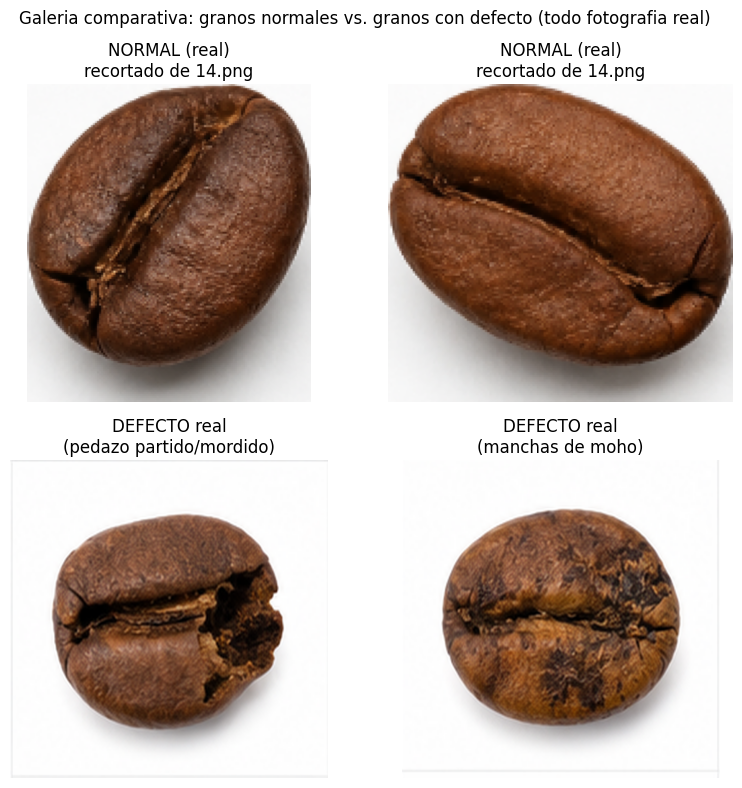

In [66]:
NOMBRE_BANDEJA_SANA = "14.png" 
NOMBRE_GRANO_DEFECTO_FORMA = "17.png"  
NOMBRE_GRANO_DEFECTO_COLOR = "19.png"

# Mostramos dimensiones y tipos de dato de las primeras imagenes para saber
# con que estamos trabajando (fotos reales descargadas de Pexels, por lo que
# el tamanio varia bastante de una a otra).
for nombre, imagen in list(zip(nombres_dataset, imagenes_dataset))[:5]:
    print(f"{nombre}: shape={imagen.shape}, dtype={imagen.dtype}, min={imagen.min()}, max={imagen.max()}")


def segmentar_umbral_fijo_preliminar(imagen_gris, umbral=180):
    """Version preliminar del umbral fijo (se formaliza en la Seccion 10),
    la necesitamos aqui solo para poder recortar granos individuales de una
    bandeja real y armar la galeria comparativa."""
    _, mascara = cv2.threshold(imagen_gris, umbral, 255, cv2.THRESH_BINARY_INV)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)


def recortar_granos_de_bandeja(bandeja_rgb, num_granos=2, lado_canvas=700):
    """Segmenta una bandeja real con varios granos y devuelve recortes
    individuales de los primeros 'num_granos' encontrados, para poder
    mostrarlos como ejemplos de granos 'normales' reales."""
    bandeja_rgb = cv2.resize(bandeja_rgb, (lado_canvas, lado_canvas))
    gris = cv2.cvtColor(bandeja_rgb, cv2.COLOR_RGB2GRAY)
    mascara = segmentar_umbral_fijo_preliminar(gris)
    num_etiquetas, etiquetas, estadisticas, _ = cv2.connectedComponentsWithStats(mascara, connectivity=8)
    recortes = []
    for etiqueta in range(1, num_etiquetas):
        if estadisticas[etiqueta, cv2.CC_STAT_AREA] < 200:
            continue
        x = estadisticas[etiqueta, cv2.CC_STAT_LEFT]
        y = estadisticas[etiqueta, cv2.CC_STAT_TOP]
        w = estadisticas[etiqueta, cv2.CC_STAT_WIDTH]
        h = estadisticas[etiqueta, cv2.CC_STAT_HEIGHT]
        recortes.append(bandeja_rgb[y:y + h, x:x + w])
        if len(recortes) >= num_granos:
            break
    return recortes


bandeja_sana_rgb = obtener_imagen_por_nombre(NOMBRE_BANDEJA_SANA)
granos_sanos_recortados = recortar_granos_de_bandeja(bandeja_sana_rgb, num_granos=2)
granos_defecto_reales = [
    obtener_imagen_por_nombre(NOMBRE_GRANO_DEFECTO_FORMA),
    obtener_imagen_por_nombre(NOMBRE_GRANO_DEFECTO_COLOR),
]

fig, ejes = plt.subplots(2, 2, figsize=(8, 8))
ejes[0, 0].imshow(granos_sanos_recortados[0])
ejes[0, 0].set_title("NORMAL (real)\nrecortado de 14.png")
ejes[0, 0].axis("off")
ejes[0, 1].imshow(granos_sanos_recortados[1])
ejes[0, 1].set_title("NORMAL (real)\nrecortado de 14.png")
ejes[0, 1].axis("off")
ejes[1, 0].imshow(granos_defecto_reales[0])
ejes[1, 0].set_title("DEFECTO real\n(pedazo partido/mordido)")
ejes[1, 0].axis("off")
ejes[1, 1].imshow(granos_defecto_reales[1])
ejes[1, 1].set_title("DEFECTO real\n(manchas de moho)")
ejes[1, 1].axis("off")
plt.suptitle("Galeria comparativa: granos normales vs. granos con defecto (todo fotografia real)")
plt.tight_layout()
plt.show()

## **Sección 4:** Preprocesamiento estandarizado 

En esta sección convertimos cada imagen a escala de grises y
redimensionamos a un tamaño fijo.

Esta sección es importante porque comparar histogramas, bordes o áreas
entre imágenes solo tiene sentido si todas estan en la misma escala y con la
misma resolución; si no, una imagen mas grande "gana" artificialmente en
cualquier métrica basada en conteo de píxeles.

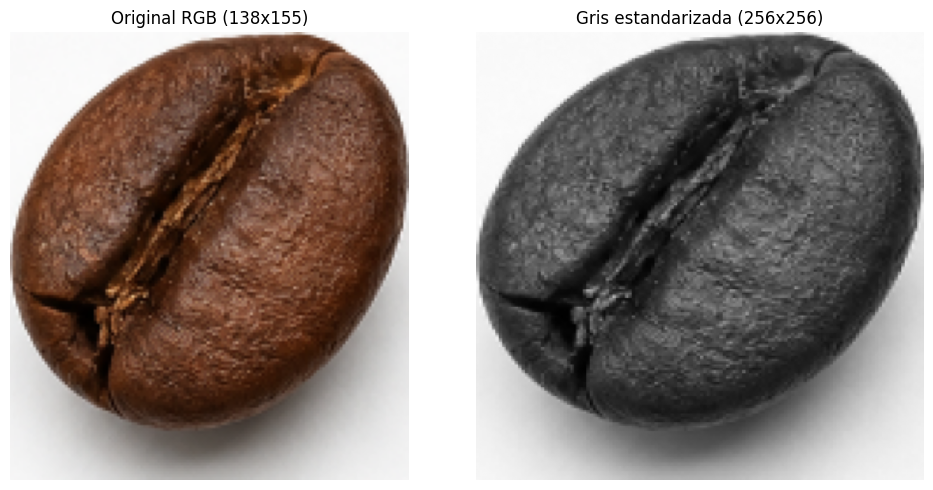

Se preprocesaron 19 imagenes a escala de grises 256x256.


In [67]:
ANCHO_ESTANDAR = 256
ALTO_ESTANDAR = 256


def preprocesar_imagen(imagen_rgb, ancho=ANCHO_ESTANDAR, alto=ALTO_ESTANDAR):
    """Convierte a escala de grises y redimensiona a un tamano comun.
    Usamos cv2.INTER_AREA porque es la interpolacion recomendada por OpenCV
    cuando se reduce el tamano de una imagen (evita artefactos de aliasing)."""
    imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    imagen_gris_reescalada = cv2.resize(imagen_gris, (ancho, alto), interpolation=cv2.INTER_AREA)
    return imagen_gris_reescalada


imagen_ejemplo_rgb = granos_sanos_recortados[0]
imagen_ejemplo_gris = preprocesar_imagen(imagen_ejemplo_rgb)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(imagen_ejemplo_rgb)
ejes[0].set_title(f"Original RGB ({imagen_ejemplo_rgb.shape[1]}x{imagen_ejemplo_rgb.shape[0]})")
ejes[0].axis("off")
ejes[1].imshow(imagen_ejemplo_gris, cmap="gray")
ejes[1].set_title(f"Gris estandarizada ({ANCHO_ESTANDAR}x{ALTO_ESTANDAR})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

imagenes_gris = [preprocesar_imagen(imagen) for imagen in imagenes_dataset]
print(f"Se preprocesaron {len(imagenes_gris)} imagenes a escala de grises {ANCHO_ESTANDAR}x{ALTO_ESTANDAR}.")

## **Sección 5:** Ajuste de brillo y contraste

Esta seccion es importante porque una cámara de inspección real no
siempre entrega imágenes con un contraste ideal entre el objeto y el fondo;
saber ajustar brillo/contraste "a mano" ayuda a entender que hacen por
detras herramientas mas automaticas (como la ecualizacion de histograma).

Resulta últil para resaltar mejor el contorno del grano frente al fondo antes
de pasar a los filtros de ruido, bordes y segmentacion.

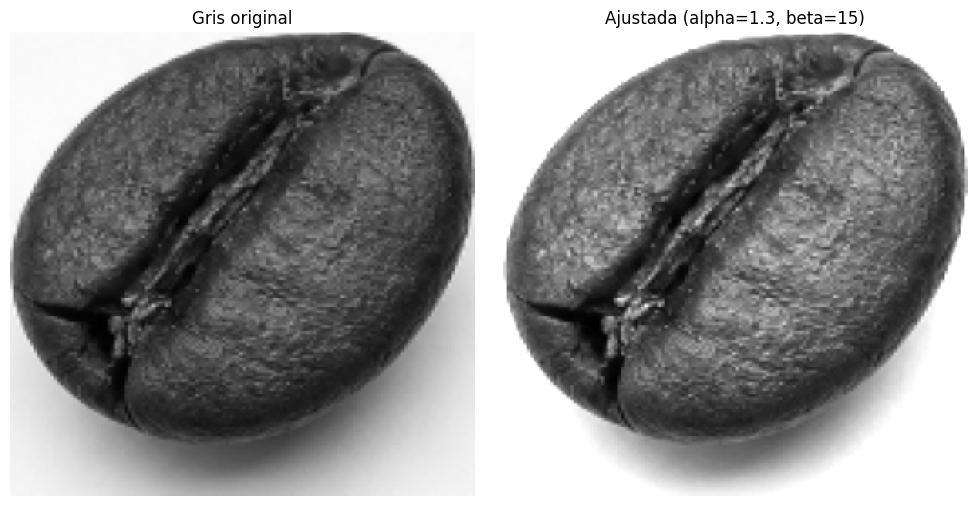

In [68]:
FACTOR_CONTRASTE_ALPHA = 1.3  
DESPLAZAMIENTO_BRILLO_BETA = 15 


def ajustar_brillo_contraste(imagen_gris, alpha=FACTOR_CONTRASTE_ALPHA, beta=DESPLAZAMIENTO_BRILLO_BETA):
    """
    Aplica la transformacion lineal de brillo/contraste: salida = alpha*entrada + beta.
    alpha controla el contraste (separa los tonos oscuros de los claros) y
    beta controla el brillo general (corrimiento aditivo). Usamos
    cv2.convertScaleAbs porque ya se encarga de saturar los valores fuera de
    [0, 255] en lugar de dejar que 'den la vuelta' (overflow silencioso de uint8).
    """
    return cv2.convertScaleAbs(imagen_gris, alpha=alpha, beta=beta)


imagen_ajustada = ajustar_brillo_contraste(imagen_ejemplo_gris)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(imagen_ejemplo_gris, cmap="gray")
ejes[0].set_title("Gris original")
ejes[0].axis("off")
ejes[1].imshow(imagen_ajustada, cmap="gray")
ejes[1].set_title(f"Ajustada (alpha={FACTOR_CONTRASTE_ALPHA}, beta={DESPLAZAMIENTO_BRILLO_BETA})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

**Justificación:** el fondo de nuestras fotos es claro y el grano tostado es marron oscuro, por lo que ya hay bastante contraste natural; usamos un alpha moderado (1.3) para acentuar un poco mas esa diferencia sin quemar (saturar a 255) demasiados pixeles del fondo, y un beta pequeño (+15) para compensar fotos ligeramente subexpuestas.

## **Sección 6:** Ruido y suavizado

En esta sección se simula ruido tipo "sal y pimienta" sobre la imagen
de ejemplo (esto si se simula a proposito, es la forma estandar de probar un
filtro de suavizado) y se compara el resultado de suavizarla con un filtro
Gaussiano (`cv2.GaussianBlur`) contra un filtro de mediana (`cv2.medianBlur`).

Esto es importante ya que en un entorno industrial real las
imagenes casi nunca llegan perfectamente limpias (polvo en el lente, sensor
barato, vibración de la banda transportadora), y el filtro elegido debe
ajustarse al tipo de ruido presente.

Con esto se logra justificar, con evidencia visual, que filtro conviene usar
antes de segmentar, ya que un suavizado mal elegido puede borrar bordes
importantes o dejar ruido residual que despues se cuenta como "objetos" falsos.

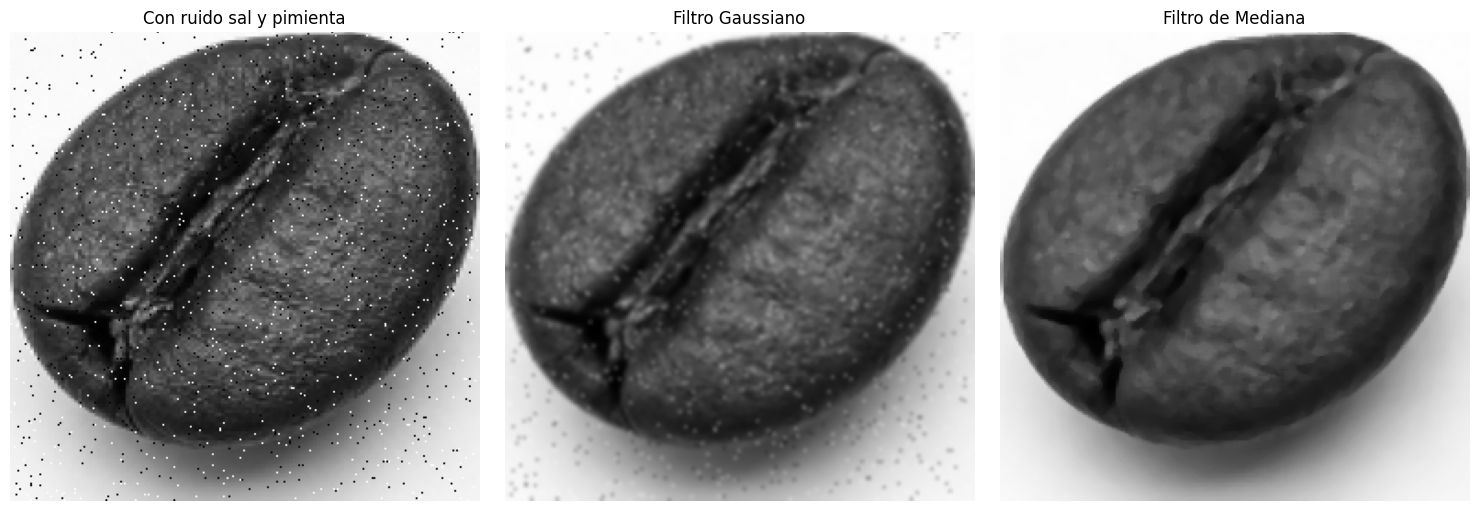

In [69]:
TAMANO_KERNEL_SUAVIZADO = 5 
CANTIDAD_RUIDO_SAL_PIMIENTA = 0.02


def agregar_ruido_sal_pimienta(imagen_gris, cantidad=CANTIDAD_RUIDO_SAL_PIMIENTA, semilla=0):
    """Simulamos ruido tipo sal y pimienta (pixeles aislados en 0 o 255),
    comun en sensores baratos o con particulas de polvo, para poder poner a
    prueba los filtros de suavizado de forma controlada."""
    generador = np.random.RandomState(semilla)
    imagen_ruidosa = imagen_gris.copy()
    total_pixeles = imagen_gris.size
    num_pixeles_sal = int(cantidad * total_pixeles / 2)
    num_pixeles_pimienta = int(cantidad * total_pixeles / 2)

    coords_sal = [generador.randint(0, dimension, num_pixeles_sal) for dimension in imagen_gris.shape]
    imagen_ruidosa[coords_sal[0], coords_sal[1]] = 255

    coords_pimienta = [generador.randint(0, dimension, num_pixeles_pimienta) for dimension in imagen_gris.shape]
    imagen_ruidosa[coords_pimienta[0], coords_pimienta[1]] = 0

    return imagen_ruidosa


imagen_con_ruido = agregar_ruido_sal_pimienta(imagen_ejemplo_gris, semilla=SEMILLA_ALEATORIA)
imagen_filtro_gaussiano = cv2.GaussianBlur(imagen_con_ruido, (TAMANO_KERNEL_SUAVIZADO, TAMANO_KERNEL_SUAVIZADO), 0)
imagen_filtro_mediana = cv2.medianBlur(imagen_con_ruido, TAMANO_KERNEL_SUAVIZADO)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))
ejes[0].imshow(imagen_con_ruido, cmap="gray")
ejes[0].set_title("Con ruido sal y pimienta")
ejes[0].axis("off")
ejes[1].imshow(imagen_filtro_gaussiano, cmap="gray")
ejes[1].set_title("Filtro Gaussiano")
ejes[1].axis("off")
ejes[2].imshow(imagen_filtro_mediana, cmap="gray")
ejes[2].set_title("Filtro de Mediana")
ejes[2].axis("off")
plt.tight_layout()
plt.show()


**Justificación:** para ruido sal y pimienta el filtro de MEDIANA es mejor, porque reemplaza cada pixel por el valor central (mediana) de su vecindad, lo que elimina los valores extremos (0 y 255) sin promediarlos con el resto. El filtro Gaussiano, en cambio, SI promedia esos extremos con sus vecinos, dejando un halo borroso alrededor de cada pixel de ruido. Por eso, para limpiar nuestras imagenes antes de segmentar, usaremos cv2.medianBlur en el resto del ejercicio.

## **Sección 7:** Comparación de histogramas (normal vs. defecto)

Antes de construir un pipeline de segmentacion completo conviene preguntarse: 
¿el histograma de intensidades, por si solo, ya alcanza para distinguir un grano 
normal de uno defectuoso?

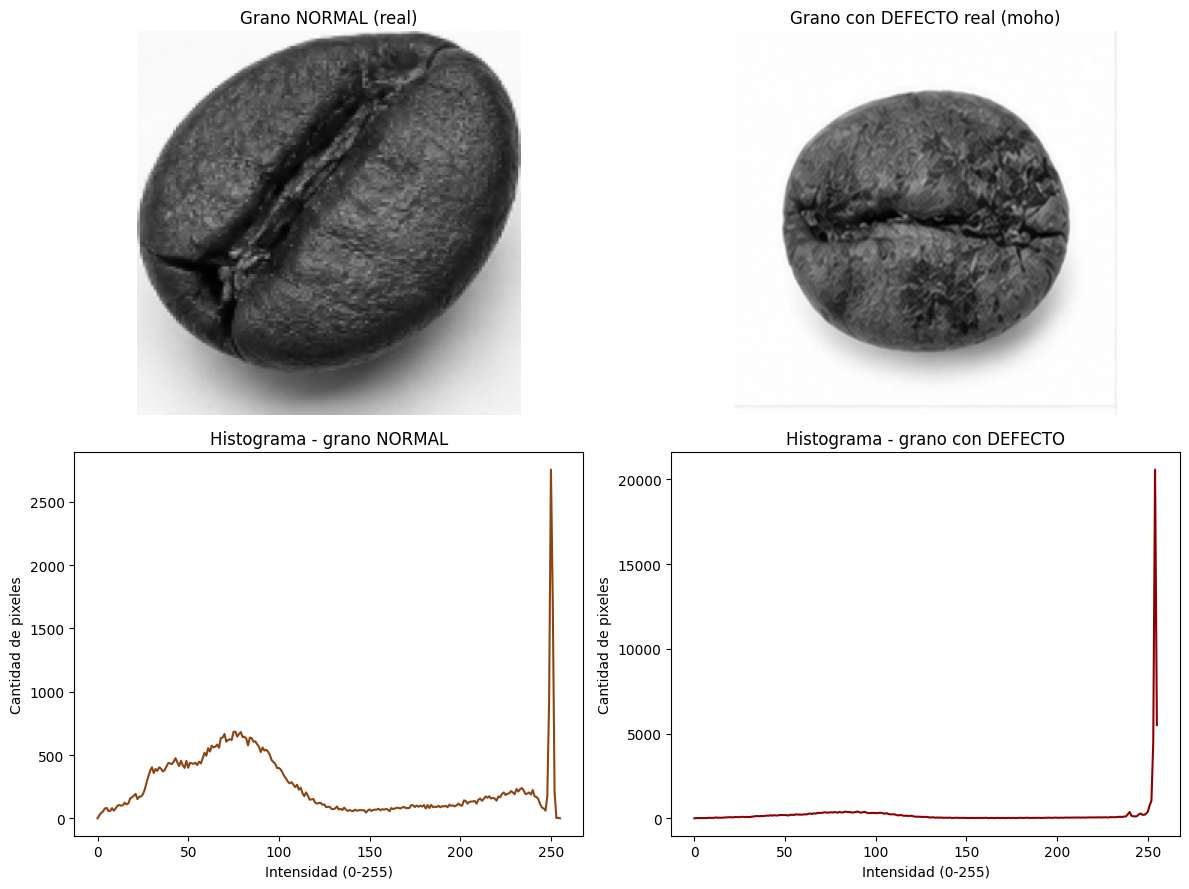

In [70]:
NUM_BINS_HISTOGRAMA = 256

def calcular_histograma_gris(imagen_gris, num_bins=NUM_BINS_HISTOGRAMA):
    """Calcula el histograma de intensidades de una imagen en escala de grises."""
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=num_bins, range=(0, 256))
    return histograma, bordes


imagen_defecto_rgb = obtener_imagen_por_nombre(NOMBRE_GRANO_DEFECTO_COLOR)
imagen_defecto_gris = preprocesar_imagen(imagen_defecto_rgb)

histograma_normal, _ = calcular_histograma_gris(imagen_ejemplo_gris)
histograma_defecto, _ = calcular_histograma_gris(imagen_defecto_gris)

fig, ejes = plt.subplots(2, 2, figsize=(12, 9))
ejes[0, 0].imshow(imagen_ejemplo_gris, cmap="gray")
ejes[0, 0].set_title("Grano NORMAL (real)")
ejes[0, 0].axis("off")
ejes[0, 1].imshow(imagen_defecto_gris, cmap="gray")
ejes[0, 1].set_title("Grano con DEFECTO real (moho)")
ejes[0, 1].axis("off")

ejes[1, 0].plot(histograma_normal, color="saddlebrown")
ejes[1, 0].set_title("Histograma - grano NORMAL")
ejes[1, 0].set_xlabel("Intensidad (0-255)")
ejes[1, 0].set_ylabel("Cantidad de pixeles")
ejes[1, 1].plot(histograma_defecto, color="darkred")
ejes[1, 1].set_title("Histograma - grano con DEFECTO")
ejes[1, 1].set_xlabel("Intensidad (0-255)")
ejes[1, 1].set_ylabel("Cantidad de pixeles")
plt.tight_layout()
plt.show()

**Observación:** las manchas de moho oscurecen zonas puntuales del grano, lo que agrega más peso en la zona de tonos oscuros del histograma del grano defectuoso comparado con el sano. Sin embargo la diferencia no es muy significativa, ya que un grano sano también tiene sombras y su propia grieta central oscura, así que el histograma GLOBAL por si solo NO alcanza para decidir con confianza si hay un defecto. Por eso en la Sesion 2 analizaremos los objetos de forma individual (área, forma) en lugar de solo la distribución global de intensidades de toda la imagen.

## **Sección 8:** Extracción de bordes (Sobel vs. Canny)

Los bordes marcan la frontera entre el objeto y el fondo 
(o entre distintas texturas dentro del objeto), y son la
base conceptual de la segmentacion de cada imagen.

Con esto se logra visualizar dónde están los cambios de intensidad más
fuertes del grano (su contorno externo y la grieta central).

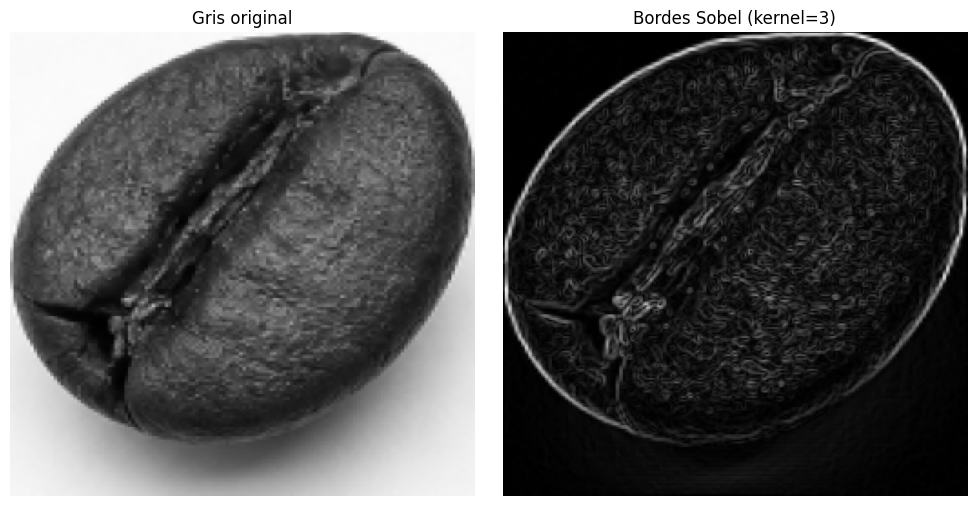

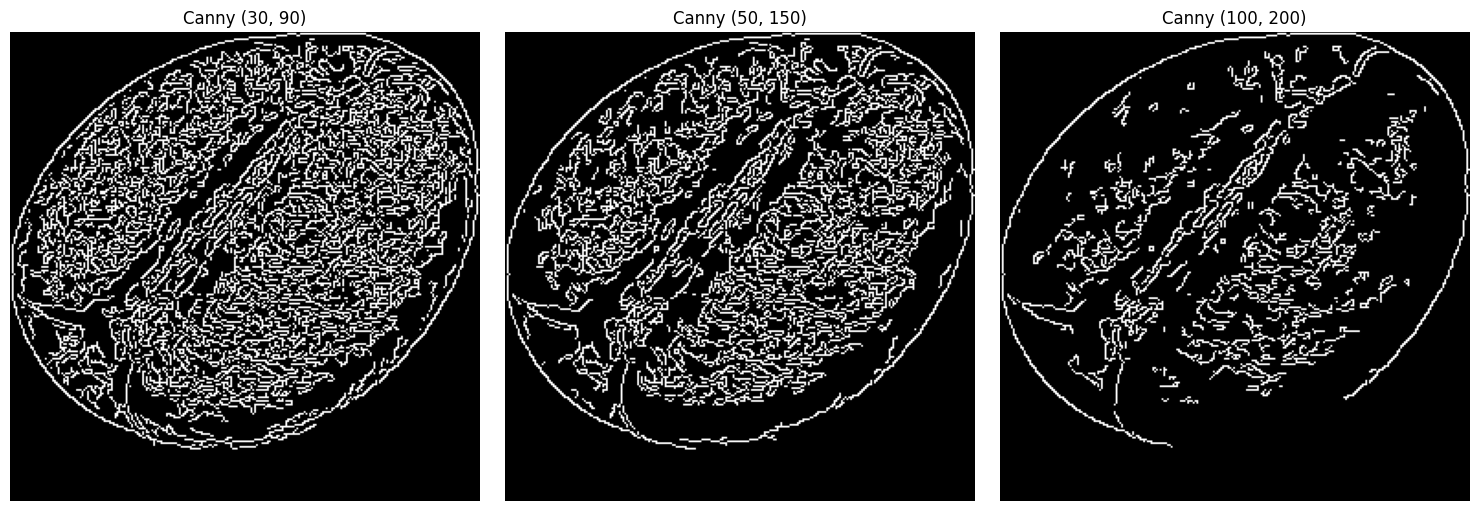

In [71]:
# Bordes con Sobel

TAMANO_KERNEL_SOBEL = 3


def extraer_bordes_sobel(imagen_gris, tamano_kernel=TAMANO_KERNEL_SOBEL):
    """Calcula el gradiente en X e Y con Sobel y combina sus magnitudes.
    Usamos CV_64F como tipo de salida intermedio para no perder los gradientes
    negativos (que se pierden si se usa directamente uint8)."""
    gradiente_x = cv2.Sobel(imagen_gris, cv2.CV_64F, 1, 0, ksize=tamano_kernel)
    gradiente_y = cv2.Sobel(imagen_gris, cv2.CV_64F, 0, 1, ksize=tamano_kernel)
    magnitud = np.sqrt(gradiente_x ** 2 + gradiente_y ** 2)
    magnitud_normalizada = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return magnitud_normalizada


bordes_sobel = extraer_bordes_sobel(imagen_ejemplo_gris)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(imagen_ejemplo_gris, cmap="gray")
ejes[0].set_title("Gris original")
ejes[0].axis("off")
ejes[1].imshow(bordes_sobel, cmap="gray")
ejes[1].set_title(f"Bordes Sobel (kernel={TAMANO_KERNEL_SOBEL})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

# Bordes con Canny

UMBRAL_CANNY_BAJO = 50  # TODO: ajustar según su dataset
UMBRAL_CANNY_ALTO = 150  # TODO: ajustar según su dataset (regla practica: alto = 2 a 3 veces el bajo)


def extraer_bordes_canny(imagen_gris, umbral_bajo=UMBRAL_CANNY_BAJO, umbral_alto=UMBRAL_CANNY_ALTO):
    return cv2.Canny(imagen_gris, umbral_bajo, umbral_alto)


pares_umbrales_prueba = [(30, 90), (50, 150), (100, 200)]  # TODO: ajustar según su dataset (pares candidatos a comparar)

fig, ejes = plt.subplots(1, len(pares_umbrales_prueba), figsize=(5 * len(pares_umbrales_prueba), 5))
for eje, (umbral_bajo, umbral_alto) in zip(ejes, pares_umbrales_prueba):
    bordes = extraer_bordes_canny(imagen_ejemplo_gris, umbral_bajo, umbral_alto)
    eje.imshow(bordes, cmap="gray")
    eje.set_title(f"Canny ({umbral_bajo}, {umbral_alto})")
    eje.axis("off")
plt.tight_layout()
plt.show()


---
# **Sesión de clase N. 2**

## **Sección 10:** Segmentación por umbral fijo

Segmentar (separar el objeto del fondo en una mascara binaria) 
es el paso que hace posible, más adelante, contar objetos y 
medir su área; es el corazón de todo el sistema de inspección.

En esta sección se realiza una umbralización global con `cv2.threshold` usando un
único valor fijo para toda la imagen, aplicada sobre una bandeja real con
varios granos de café: todo píxel más oscuro que el umbral se
marca como objeto (255) y el resto como fondo (0).

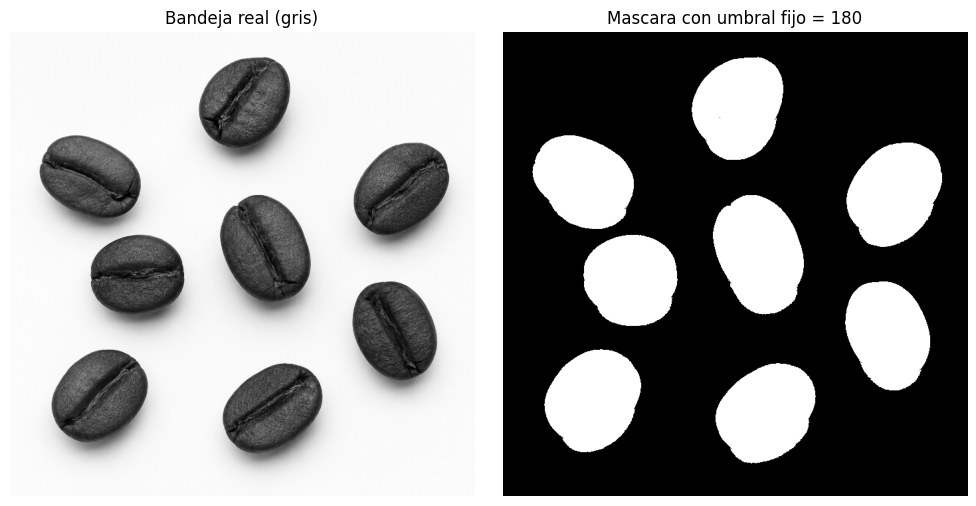

In [72]:
UMBRAL_FIJO = 180  
NOMBRE_BANDEJA_A = "14.png" 
LADO_CANVAS_BANDEJA = 700


def segmentar_umbral_fijo(imagen_gris, umbral=UMBRAL_FIJO):
    """El fondo de nuestras fotos es claro (>200 en escala de grises) y
    el objeto es mas oscuro que el fondo. Por eso usamos THRESH_BINARY_INV:
    todo lo que esta POR DEBAJO del umbral se marca como objeto (255 en la
    mascara), en lugar de al reves."""
    _, mascara = cv2.threshold(imagen_gris, umbral, 255, cv2.THRESH_BINARY_INV)
    return mascara


bandeja_a_rgb = cv2.resize(obtener_imagen_por_nombre(NOMBRE_BANDEJA_A), (LADO_CANVAS_BANDEJA, LADO_CANVAS_BANDEJA))
bandeja_a_gris = cv2.cvtColor(bandeja_a_rgb, cv2.COLOR_RGB2GRAY)
mascara_umbral_fijo = segmentar_umbral_fijo(bandeja_a_gris)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(bandeja_a_gris, cmap="gray")
ejes[0].set_title("Bandeja real (gris)")
ejes[0].axis("off")
ejes[1].imshow(mascara_umbral_fijo, cmap="gray")
ejes[1].set_title(f"Mascara con umbral fijo = {UMBRAL_FIJO}")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

## **Sección 11:** Segmentación adaptativa

Esta sección es importante porque en una banda transportadora real la
iluminación casi nunca es perfectamente uniforme (sombras, lamparas
desalineadas, reflejos), y un umbral global puede fallar justo en la zona más
oscura o mas clara de la escena.

En esta sección, en lugar de simular una sombra artificial, encontramos
en nuestro propio dataset una foto real con iluminación dispareja
(`7.jpg`, tiene una franja de sombra diagonal real causada por luz de
ventana) y comparamos sobre ella la máscara de umbral fijo contra la de
`cv2.adaptiveThreshold` (umbral local por vecindad).

Con esto se logra justificar, con evidencia real (no simulada), cual método
de segmentación conviene usar según las condiciones de iluminación del
dataset del grupo.

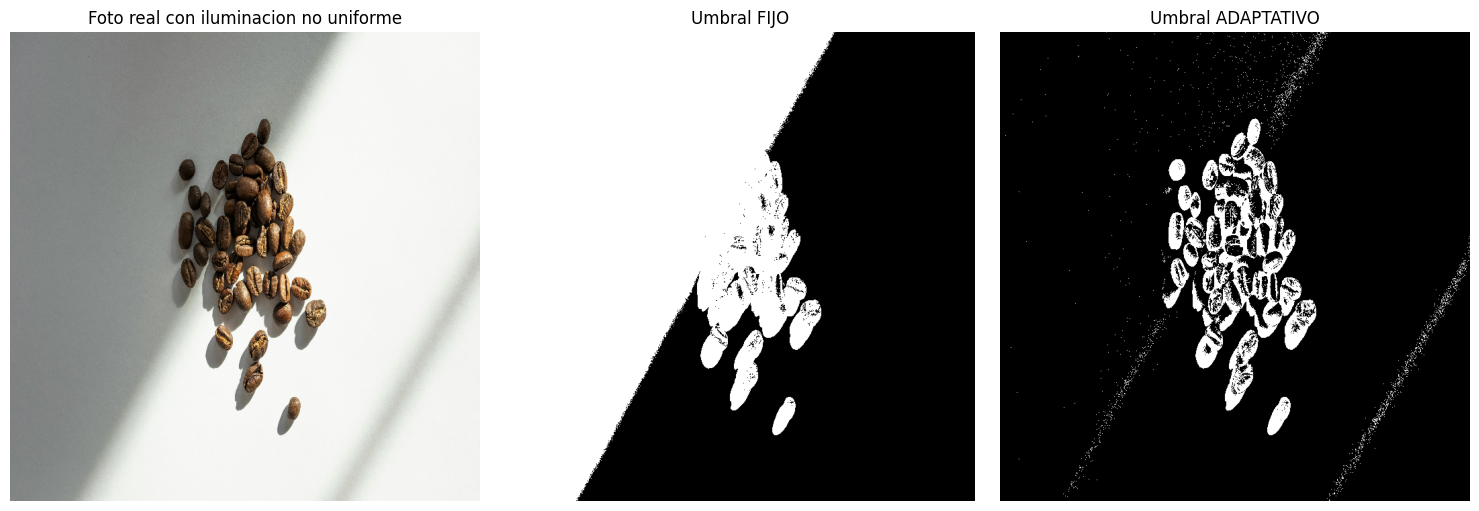

Area del blob mas grande con umbral FIJO: 233715 px^2
Area del blob mas grande con umbral ADAPTATIVO: 15378 px^2



In [73]:
NOMBRE_FOTO_ILUMINACION_DESIGUAL = "7.jpg"

TAMANO_BLOQUE_ADAPTATIVO = 51  
CONSTANTE_C_ADAPTATIVO = 10  


def segmentar_umbral_adaptativo(imagen_gris, tamano_bloque=TAMANO_BLOQUE_ADAPTATIVO, constante_c=CONSTANTE_C_ADAPTATIVO):
    """A diferencia del umbral fijo, aqui cada pixel se compara contra el
    promedio (ponderado por una Gaussiana) de su propia vecindad, por lo que
    se adapta a cambios locales de iluminacion."""
    return cv2.adaptiveThreshold(
        imagen_gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, tamano_bloque, constante_c,
    )


imagen_sombra_rgb = cv2.resize(obtener_imagen_por_nombre(NOMBRE_FOTO_ILUMINACION_DESIGUAL), (LADO_CANVAS_BANDEJA, LADO_CANVAS_BANDEJA))
imagen_sombra_gris = cv2.cvtColor(imagen_sombra_rgb, cv2.COLOR_RGB2GRAY)

mascara_fija_sombra = segmentar_umbral_fijo(imagen_sombra_gris)
mascara_adaptativa_sombra = segmentar_umbral_adaptativo(imagen_sombra_gris)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))
ejes[0].imshow(imagen_sombra_rgb)
ejes[0].set_title("Foto real con iluminacion no uniforme")
ejes[0].axis("off")
ejes[1].imshow(mascara_fija_sombra, cmap="gray")
ejes[1].set_title("Umbral FIJO")
ejes[1].axis("off")
ejes[2].imshow(mascara_adaptativa_sombra, cmap="gray")
ejes[2].set_title("Umbral ADAPTATIVO")
ejes[2].axis("off")
plt.tight_layout()
plt.show()

# Contamos componentes conexos en cada mascara para evidenciar el problema:
# con la sombra real, el umbral fijo tiende a FUNDIR varios granos con la
# zona oscurecida del fondo en un solo blob gigante.
_, _, estadisticas_fija, _ = cv2.connectedComponentsWithStats(mascara_fija_sombra, connectivity=8)
_, _, estadisticas_adapt, _ = cv2.connectedComponentsWithStats(mascara_adaptativa_sombra, connectivity=8)
area_mayor_fija = estadisticas_fija[1:, cv2.CC_STAT_AREA].max() if len(estadisticas_fija) > 1 else 0
area_mayor_adapt = estadisticas_adapt[1:, cv2.CC_STAT_AREA].max() if len(estadisticas_adapt) > 1 else 0
print(f"Area del blob mas grande con umbral FIJO: {area_mayor_fija} px^2")
print(f"Area del blob mas grande con umbral ADAPTATIVO: {area_mayor_adapt} px^2")

print()

**Justificación:** en esta foto, el umbral FIJO funde varios granos con su sombra en un solo blob gigante, porque usa un único valor global para toda la imagen. El umbral ADAPTATIVO calcula un umbral local por vecindad, por lo que separa mejor los granos individuales bajo la misma iluminación dispareja (aunque deja algo más de ruido fino, fácil de limpiar después con morfología). Para las bandejas del grupo con iluminación uniforme seguiremos usando umbral FIJO por ser más simple y rápido; dejamos el adaptativo documentado como la opción recomendada si se trabajara con fotos de iluminación despareja.

## **Sección 12:** Limpieza morfológica (cierre morfológico) sobre la máscara binaria

Esta sección es importante porque una mascara binaria "cruda" casi
siempre tiene huequitos internos (por ejemplo, brillos especulares dentro del
objeto que quedaron mal segmentados) que, si no se corrigen, pueden hacer que
el conteo de componentes conexos de la siguiente sección se equivoque.

Sirve para dejar una máscara binaria "solida" (sin huecos internos)
lista para el conteo de objetos y la extracción de rasgos por objeto.

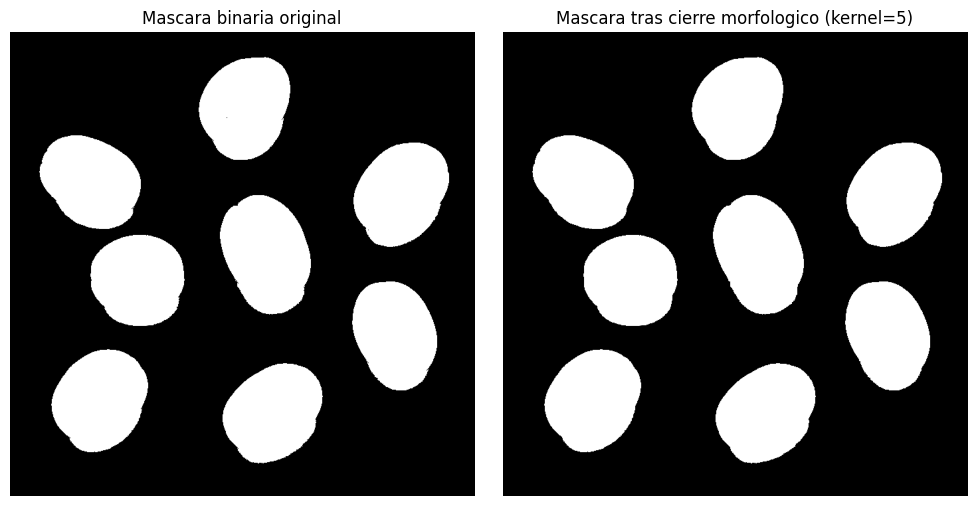

In [74]:
TAMANO_KERNEL_MORFOLOGICO = 5


def limpiar_mascara_morfologicamente(mascara, tamano_kernel=TAMANO_KERNEL_MORFOLOGICO):
    """
    El cierre morfologico (dilatacion seguida de erosion) rellena pequenios
    huecos internos sin cambiar demasiado el tamano externo del objeto. Usamos
    un kernel eliptico porque respeta mejor los contornos redondeados de un
    grano de cafe que un kernel rectangular.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tamano_kernel, tamano_kernel))
    mascara_cerrada = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    return mascara_cerrada


mascara_limpia = limpiar_mascara_morfologicamente(mascara_umbral_fijo)

fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
ejes[0].imshow(mascara_umbral_fijo, cmap="gray")
ejes[0].set_title("Mascara binaria original")
ejes[0].axis("off")
ejes[1].imshow(mascara_limpia, cmap="gray")
ejes[1].set_title(f"Mascara tras cierre morfologico (kernel={TAMANO_KERNEL_MORFOLOGICO})")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

## **Sección 13:** Conteo de objetos por imagen (vaidación contra conteo manual)

Aplicamos el pipeline de segmentacion + limpieza + componentes conexos 
sobre cuatro imagenes de nuestro dataset que efectivamente traen varios
granos de cafe ya separados sobre fondo claro. Comparamos el conteo automatico
contra el conteo manual que hicimos nosotros mismos mirando cada imagen.

14.png: conteo manual=8, el algoritmo conto 8 -> OK
15.png: conteo manual=8, el algoritmo conto 8 -> OK
2.jpg: conteo manual=19, el algoritmo conto 19 -> OK
18.png: conteo manual=9, el algoritmo conto 9 -> OK


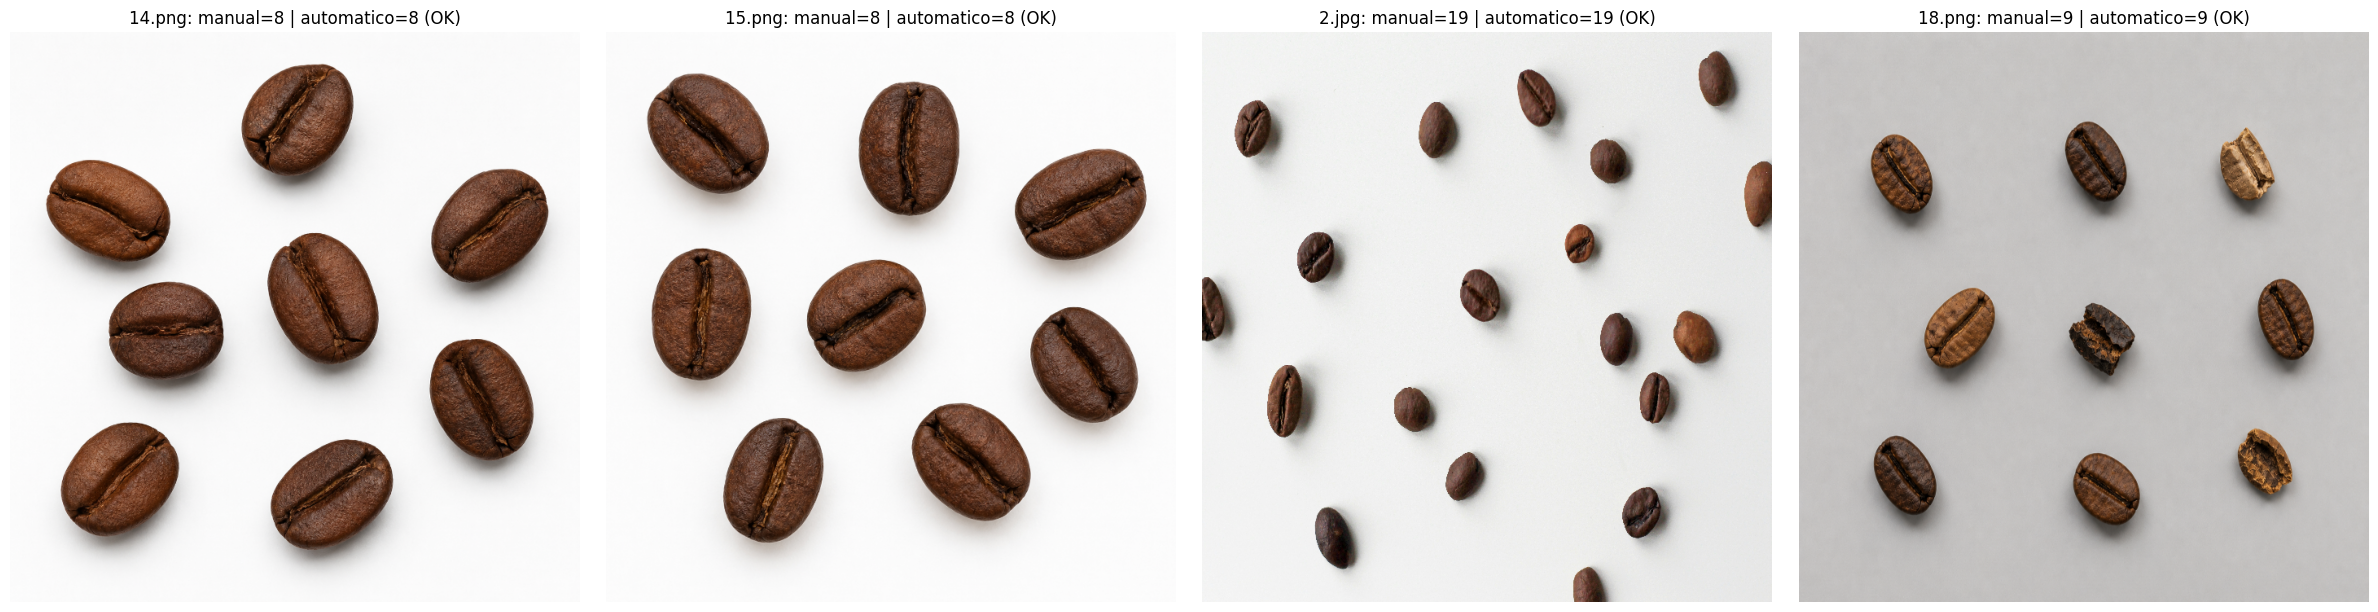

In [75]:
AREA_MINIMA_OBJETO = 500

# Las 3 bandejas reales elegidas y su conteo MANUAL (lo contamos nosotros a ojo
# mirando cada foto antes de correr el algoritmo).
NOMBRES_BANDEJAS_VALIDACION = ["14.png", "15.png", "2.jpg", "18.png"]
CONTEOS_MANUALES = {"14.png": 8, "15.png": 8, "2.jpg": 19, "18.png": 9}


def segmentar_y_contar_objetos(imagen_rgb, umbral=UMBRAL_FIJO, tamano_kernel_morfologico=TAMANO_KERNEL_MORFOLOGICO,
                                area_minima=AREA_MINIMA_OBJETO):
    """Pipeline completo de segmentacion + limpieza + componentes conexos.
    area_minima descarta manchitas de ruido demasiado pequenias para ser un
    objeto real (por ejemplo, restos de la mascara que sobrevivieron al cierre
    morfologico)."""
    imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    mascara = segmentar_umbral_fijo(imagen_gris, umbral)
    mascara = limpiar_mascara_morfologicamente(mascara, tamano_kernel_morfologico)
    num_etiquetas, etiquetas, estadisticas, centroides = cv2.connectedComponentsWithStats(mascara, connectivity=8)

    objetos_validos = [
        etiqueta for etiqueta in range(1, num_etiquetas)  # la etiqueta 0 es el fondo, se descarta
        if estadisticas[etiqueta, cv2.CC_STAT_AREA] >= area_minima
    ]
    return mascara, etiquetas, estadisticas, centroides, objetos_validos


fig, ejes = plt.subplots(1, len(NOMBRES_BANDEJAS_VALIDACION), figsize=(6 * len(NOMBRES_BANDEJAS_VALIDACION), 6))
for columna, nombre_bandeja in enumerate(NOMBRES_BANDEJAS_VALIDACION):
    bandeja_rgb = cv2.resize(obtener_imagen_por_nombre(nombre_bandeja), (LADO_CANVAS_BANDEJA, LADO_CANVAS_BANDEJA))
    _, _, _, _, objetos_validos = segmentar_y_contar_objetos(bandeja_rgb)
    conteo_automatico = len(objetos_validos)
    conteo_manual = CONTEOS_MANUALES[nombre_bandeja]
    coincide = "OK" if conteo_automatico == conteo_manual else "DIFIERE"

    ejes[columna].imshow(bandeja_rgb)
    ejes[columna].set_title(f"{nombre_bandeja}: manual={conteo_manual} | automatico={conteo_automatico} ({coincide})")
    ejes[columna].axis("off")
    print(f"{nombre_bandeja}: conteo manual={conteo_manual}, el algoritmo conto {conteo_automatico} -> {coincide}")

plt.tight_layout()
plt.show()

## **Sección 14:** Extracción de rasgos por objeto (área y relación de aspecto)

Esta sección nos permitirá posteriormente decidir qué objeto es "normal" 
y cual es "defectuoso". Pero primero hay que medir de cada
objeto por separado: el área y la relacipon de aspecto son los rasgos más
simples y directos.

Usamos la bandeja `18.png`: una imagen generada con un
modelo de IA (le pedimos explícitamente un resultado hiperrealista, con
varios granos separados y 1 a 3 partidos) porque ninguna fotografía real de
nuestro dataset mostraba, de forma natural, granos sanos y partidos juntos en
la misma escena.

Con esto se deja preparada la tabla de rasgos por objeto que se usara
en la Seccion 15 para calcular el z-score del area y decidir cuales objetos
son anomalos.

Objetos detectados en la bandeja real (18.png): 9 (esperado: 9, de los cuales 3 estan partidos)
Objeto  Area (px^2)    Relacion aspecto  
0       9280           0.77              
1       6951           0.71              
2       9656           0.77              
3       9603           0.73              
4       10970          0.86              
5       8265           0.91              
6       5994           0.89              
7       9631           0.80              
8       10121          0.89              


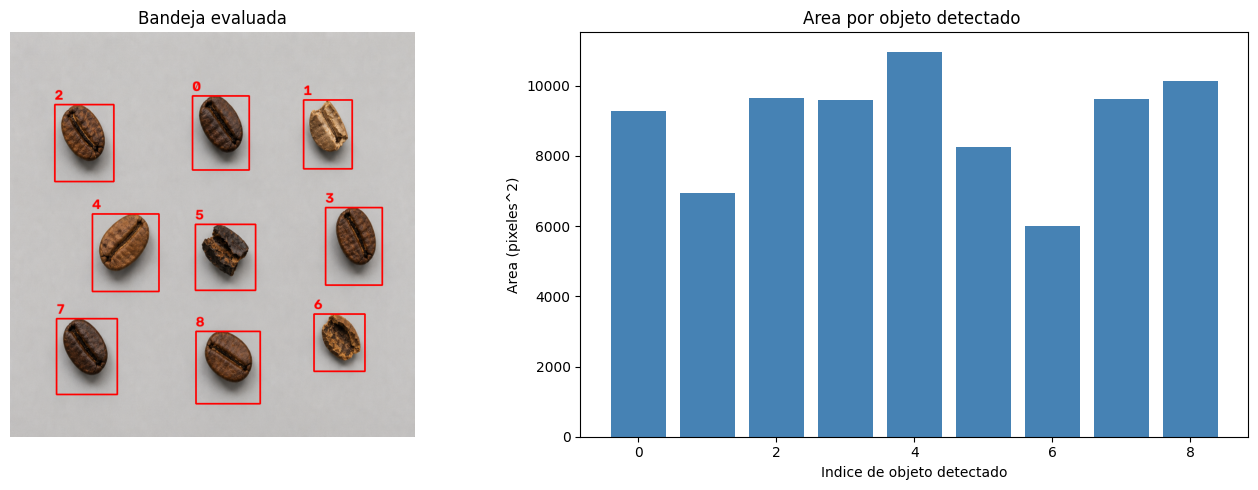

In [76]:
NOMBRE_BANDEJA_CON_DEFECTOS_REALES = "18.png"


def extraer_silueta_objeto(imagen_rgb, ancho_objetivo=140):
    """
    Recorta el objeto principal de una foto individual (fondo claro) usando
    un umbral fijo + el bounding box de su contorno mas grande, y lo reescala
    a un ancho de trabajo comun. Se usa en la Seccion 17 para obtener un grano
    suelto con el que armar la simulacion de banda transportadora. Si no se
    encuentra ningun contorno (por ejemplo, al usar el dataset de respaldo de
    skimage con fondos no uniformes), devolvemos la imagen completa sin
    recortar para que el resto del pipeline no se rompa.
    """
    imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    mascara = limpiar_mascara_morfologicamente(segmentar_umbral_fijo(imagen_gris))
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contornos) == 0:
        recorte_rgb = cv2.resize(imagen_rgb, (ancho_objetivo, ancho_objetivo), interpolation=cv2.INTER_AREA)
        recorte_mascara = np.full(recorte_rgb.shape[:2], 255, dtype=np.uint8)
        return recorte_rgb, recorte_mascara

    contorno_mayor = max(contornos, key=cv2.contourArea)
    x, y, ancho_caja, alto_caja = cv2.boundingRect(contorno_mayor)
    recorte_rgb = imagen_rgb[y:y + alto_caja, x:x + ancho_caja]
    recorte_mascara = mascara[y:y + alto_caja, x:x + ancho_caja]

    escala = ancho_objetivo / ancho_caja
    nuevo_alto = max(1, int(alto_caja * escala))
    recorte_rgb = cv2.resize(recorte_rgb, (ancho_objetivo, nuevo_alto), interpolation=cv2.INTER_AREA)
    recorte_mascara = cv2.resize(recorte_mascara, (ancho_objetivo, nuevo_alto), interpolation=cv2.INTER_NEAREST)
    return recorte_rgb, recorte_mascara


def extraer_rasgos_objetos(estadisticas, objetos_validos):
    """Para cada objeto valido devuelve su area, su bounding box y su
    relacion de aspecto (ancho/alto). La relacion de aspecto es util porque
    una pieza rota o deformada suele cambiar de forma ademas de tamano."""
    rasgos = []
    for etiqueta in objetos_validos:
        x = estadisticas[etiqueta, cv2.CC_STAT_LEFT]
        y = estadisticas[etiqueta, cv2.CC_STAT_TOP]
        ancho = estadisticas[etiqueta, cv2.CC_STAT_WIDTH]
        alto = estadisticas[etiqueta, cv2.CC_STAT_HEIGHT]
        area = estadisticas[etiqueta, cv2.CC_STAT_AREA]
        relacion_aspecto = ancho / alto if alto > 0 else 0
        rasgos.append({
            "etiqueta": etiqueta, "x": x, "y": y, "w": ancho, "h": alto,
            "area": area, "relacion_aspecto": relacion_aspecto,
        })
    return rasgos


bandeja_analisis = cv2.resize(obtener_imagen_por_nombre(NOMBRE_BANDEJA_CON_DEFECTOS_REALES), (LADO_CANVAS_BANDEJA, LADO_CANVAS_BANDEJA))
mascara_analisis, etiquetas_analisis, estadisticas_analisis, centroides_analisis, objetos_validos_analisis = (
    segmentar_y_contar_objetos(bandeja_analisis)
)
rasgos_bandeja = extraer_rasgos_objetos(estadisticas_analisis, objetos_validos_analisis)

print(f"Objetos detectados en la bandeja real (18.png): {len(rasgos_bandeja)} (esperado: 9, de los cuales 3 estan partidos)")
print(f"{'Objeto':<8}{'Area (px^2)':<15}{'Relacion aspecto':<18}")
for indice, rasgo in enumerate(rasgos_bandeja):
    print(f"{indice:<8}{rasgo['area']:<15}{rasgo['relacion_aspecto']:<18.2f}")

bandeja_con_indices = bandeja_analisis.copy()
for indice, rasgo in enumerate(rasgos_bandeja):
    cv2.putText(
        bandeja_con_indices, str(indice),
        (rasgo["x"], max(20, rasgo["y"] - 8)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2,
    )
    cv2.rectangle(
        bandeja_con_indices, (rasgo["x"], rasgo["y"]),
        (rasgo["x"] + rasgo["w"], rasgo["y"] + rasgo["h"]), (255, 0, 0), 2,
    )

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
ejes[0].imshow(bandeja_con_indices)
ejes[0].set_title("Bandeja evaluada")
ejes[0].axis("off")
ejes[1].bar(range(len(areas_objetos)), areas_objetos, color="steelblue")
ejes[1].set_xlabel("Indice de objeto detectado")
ejes[1].set_ylabel("Area (pixeles^2)")
ejes[1].set_title("Area por objeto detectado ")
plt.tight_layout()
plt.show()

## **Sección 15:** Detección de anomalías por z-score sobre el area (umbral Z ajustable)

Esta sección es importante porque es el corazon estadistico del
sistema de inspección: convierte una medida (el área de cada objeto) en una
decisión binaria (OK / DEFECTO) de forma automática y ajustable.

Aquí se implementa el cálculo del z-score del area de cada objeto
respecto a la media y desviacion estandar del area de todos los objetos de la
misma imagen, y se marca como anomalía todo objeto cuyo `|z| > umbral_z`.

Sirve para identificar automáticamente, dentro de una escena con
varios objetos del mismo tipo, cual de ellos tiene un tamaño
"estadísticamente distinto" al resto (en nuestro caso, los granos
partidos), sin necesidad de fijar un area mínima/máxima
absoluta a mano.

Objeto  Area      Z-score     Diagnostico 
0       9280      0.23        OK          
1       6951      -1.33       DEFECTO     
2       9656      0.48        OK          
3       9603      0.44        OK          
4       10970     1.36        DEFECTO     
5       8265      -0.45       OK          
6       5994      -1.97       DEFECTO     
7       9631      0.46        OK          
8       10121     0.79        OK          
RESUMEN DE INSPECCION
  Objetos detectados: 9
  OK: 6
  DEFECTO: 3


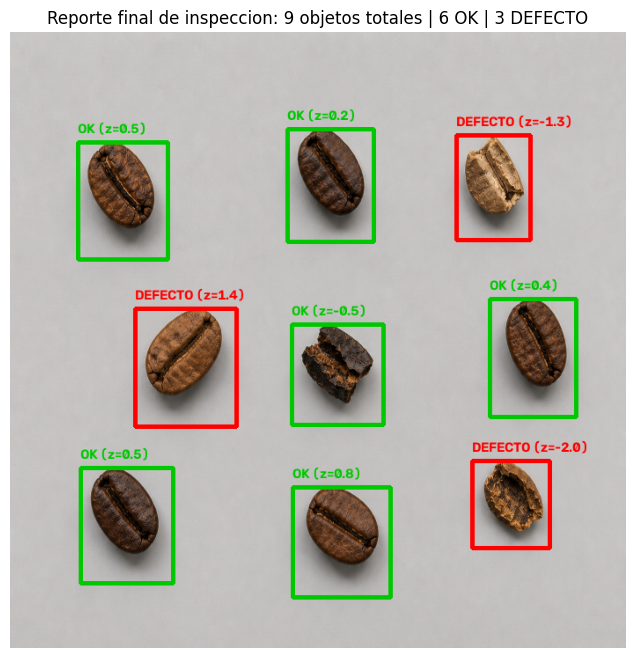

In [77]:
UMBRAL_Z_SCORE = 1.0


def detectar_anomalias_zscore(rasgos_objetos, umbral_z=UMBRAL_Z_SCORE):
    """
    Calcula el z-score del area de cada objeto respecto a la media y
    desviacion estandar del area de todos los objetos de la MISMA imagen:

        z = (area_objeto - area_promedio) / desviacion_estandar_area

    Un area demasiado chica o demasiado grande respecto al resto (|z| >
    umbral_z) se marca como anomalia (posible pieza rota, incompleta, o un
    objeto que no deberia estar ahi).
    """
    areas = np.array([rasgo["area"] for rasgo in rasgos_objetos], dtype=np.float64)
    area_promedio = areas.mean()
    desviacion_area = areas.std()

    for rasgo in rasgos_objetos:
        if desviacion_area > 0:
            z_score = (rasgo["area"] - area_promedio) / desviacion_area
        else:
            z_score = 0.0  # si todas las areas son identicas, no hay anomalia posible
        rasgo["z_score_area"] = z_score
        rasgo["es_defecto"] = abs(z_score) > umbral_z

    return rasgos_objetos


rasgos_bandeja = detectar_anomalias_zscore(rasgos_bandeja)

print(f"{'Objeto':<8}{'Area':<10}{'Z-score':<12}{'Diagnostico':<12}")
for indice, rasgo in enumerate(rasgos_bandeja):
    diagnostico = "DEFECTO" if rasgo["es_defecto"] else "OK"
    print(f"{indice:<8}{rasgo['area']:<10}{rasgo['z_score_area']:<12.2f}{diagnostico:<12}")


def generar_reporte_visual(imagen_rgb, rasgos_objetos):
    """Dibuja un rectangulo verde sobre los objetos OK y uno rojo sobre los
    marcados como defecto, junto con su z-score, para el reporte final de
    inspeccion."""
    imagen_reporte = imagen_rgb.copy()
    for rasgo in rasgos_objetos:
        color = (255, 0, 0) if rasgo["es_defecto"] else (0, 200, 0)
        etiqueta_texto = "DEFECTO" if rasgo["es_defecto"] else "OK"
        cv2.rectangle(
            imagen_reporte, (rasgo["x"], rasgo["y"]),
            (rasgo["x"] + rasgo["w"], rasgo["y"] + rasgo["h"]), color, 3,
        )
        cv2.putText(
            imagen_reporte, f"{etiqueta_texto} (z={rasgo['z_score_area']:.1f})",
            (rasgo["x"], max(20, rasgo["y"] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2,
        )
    return imagen_reporte


reporte_final = generar_reporte_visual(bandeja_analisis, rasgos_bandeja)

num_objetos_ok = sum(1 for rasgo in rasgos_bandeja if not rasgo["es_defecto"])
num_objetos_defecto = sum(1 for rasgo in rasgos_bandeja if rasgo["es_defecto"])


print("RESUMEN DE INSPECCION")
print(f"  Objetos detectados: {len(rasgos_bandeja)}")
print(f"  OK: {num_objetos_ok}")
print(f"  DEFECTO: {num_objetos_defecto}")

plt.figure(figsize=(10, 8))
plt.imshow(reporte_final)
plt.title(
    f"Reporte final de inspeccion: {len(rasgos_bandeja)} objetos totales | "
    f"{num_objetos_ok} OK | {num_objetos_defecto} DEFECTO"
)
plt.axis("off")
plt.show()

**Nota sobre el umbral elegido (esto nos tomo dos intentos):** 

Al medir los 3 granos partidos de `18.png` encontramos que los tres no se
partieron "igual de mal": uno quedo con z=-1.97 (un fragmento bastante
chico), otro con z=-1.33 y el tercero con apenas z=-0.45 (el trozo que quedo
todavia ocupa casi el mismo espacio que un grano entero, aunque a simple
vista se vea claramente roto). Con el umbral clasico de 1.5 solo se detectaba
1 de los 3.

Probamos bajar `UMBRAL_Z_SCORE` a 1.0 esperando destapar los otros dos, pero
al hacerlo apareció un problema que no habíamos anticipado: uno de los
granos SANOS y enteros (sin ningún dano) tiene z=+1.36, porque simplemente es
un poco mas grande que el promedio del resto (variacion natural de tamaño
entre granos). Ese valor está tan cerca del z=-1.33 del segundo grano
partido que no existe ningun umbral que agarre a los dos granos partidos
sin también marcar a ese grano sano como falso positivo. Con
`UMBRAL_Z_SCORE=1.0` el resultado final es: 2 de los 3 granos partidos
detectados correctamente, 1 grano sano marcado por error (falso positivo), y
el grano partido más leve sigue sin detectarse (falso negativo).

Decidimos dejarlo así, en lugar de subir el umbral para "esconder" el
problema, porque es la demostración más honesta de una limitación real del
método: el área por si sola no siempre alcanza para separar "sano" de
"defectuoso" cuando la variación natural de tamaño entre objetos sanos se
solapa con la reducción de tamaño de un objeto dañado. Un sistema de
inspección real necesitaría una segunda señal (por ejemplo, textura o color
de la superficie partida) para resolver este caso con confianza.

**Resultado:**

- 2 de los 3 granos realmente partidos SI quedan marcados como DEFECTO.

- 1 grano SANO y entero queda marcado como DEFECTO por error (falso positivo): 
su área es grande pero por variación natural, no por daño.

- 1 grano partido (el de menor reduccion de area) NO queda detectado (falso negativo): 
a simple vista se ve roto, pero su area no baja lo suficiente para distinguirse 
estadisticamente de un grano sano.

---
# **BONUS**

## **Sección 16:** Simulación de banda transportadora

Un sistema de inspección real no analiza fotos aisladas: analiza un 
video (una secuencia de fotogramas) de objetos pasando frente a una
cámara fija sobre una banda transportadora.

A partir de una sola foto real de un grano sano, se generan varios
fotogramas desplazandola horizontalmente con una matriz de traslación
aplicada mediante `cv2.warpAffine`, simulando el movimiento de un objeto 
sobre una banda.

Con esto se tiene una mini-secuencia de video sintética sobre la cual
probar, en las siguientes secciones bonus, detección de centroides y tracking
por fotograma.

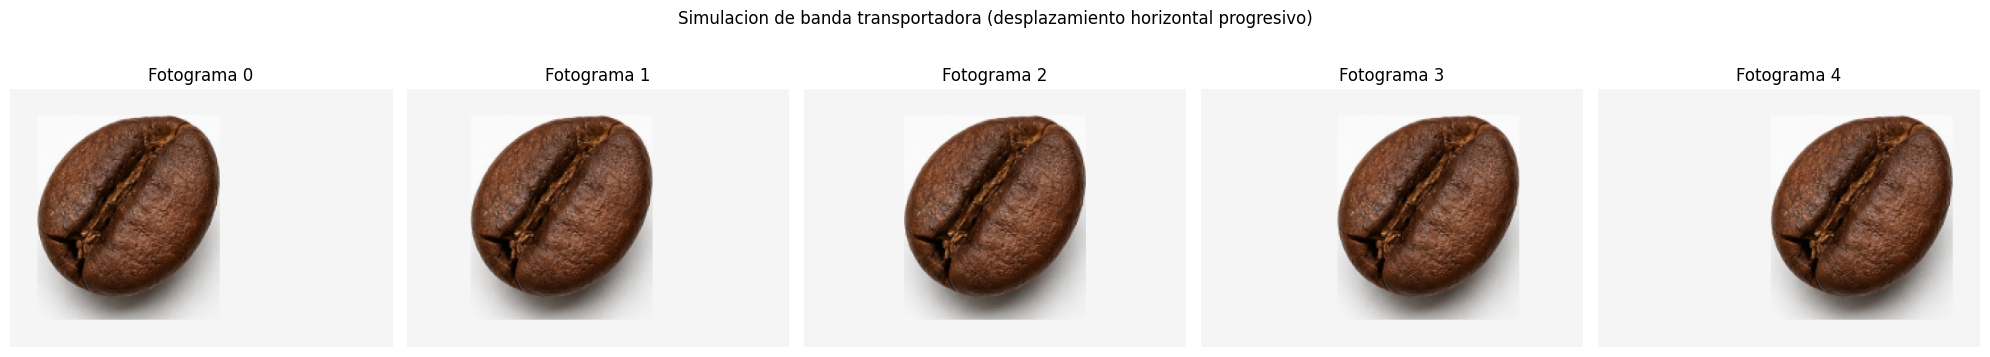

In [78]:
NUM_FOTOGRAMAS_SIMULACION = 5 
DESPLAZAMIENTO_PX_POR_FOTOGRAMA = 40


def generar_fotogramas_banda(imagen_rgb, num_fotogramas=NUM_FOTOGRAMAS_SIMULACION,
                              desplazamiento_px=DESPLAZAMIENTO_PX_POR_FOTOGRAMA):
    """
    A partir de UNA sola foto, generamos varios fotogramas desplazando el
    contenido horizontalmente con una matriz de traslacion 2x3 (warpAffine),
    para simular como se veria un mismo objeto pasando por una banda
    transportadora frente a una camara fija.
    """
    alto, ancho = imagen_rgb.shape[:2]
    fotogramas = []
    for indice_fotograma in range(num_fotogramas):
        desplazamiento_x = indice_fotograma * desplazamiento_px
        matriz_traslacion = np.float32([[1, 0, desplazamiento_x], [0, 1, 0]])
        fotograma = cv2.warpAffine(
            imagen_rgb, matriz_traslacion, (ancho, alto), borderValue=(245, 245, 245)
        )
        fotogramas.append(fotograma)
    return fotogramas


imagen_base_banda_rgb, _ = extraer_silueta_objeto(granos_sanos_recortados[0], ancho_objetivo=200)
# Pegamos el grano recortado sobre un lienzo mas grande para tener espacio de sobra al
# desplazarlo (el alto del lienzo se calcula a partir del alto real del grano recortado,
# que no siempre es exactamente cuadrado, para evitar que la pegada se salga del lienzo).
alto_grano, ancho_grano = imagen_base_banda_rgb.shape[:2]
margen = 30
desplazamiento_total_maximo = (NUM_FOTOGRAMAS_SIMULACION - 1) * DESPLAZAMIENTO_PX_POR_FOTOGRAMA
lienzo_base = np.full(
    (alto_grano + 2 * margen, ancho_grano + desplazamiento_total_maximo + 2 * margen, 3),
    245, dtype=np.uint8,
)
lienzo_base[margen:margen + alto_grano, margen:margen + ancho_grano] = imagen_base_banda_rgb
imagen_base_banda = lienzo_base

fotogramas_banda = generar_fotogramas_banda(imagen_base_banda)

fig, ejes = plt.subplots(1, len(fotogramas_banda), figsize=(4 * len(fotogramas_banda), 4))
for indice_fotograma, (eje, fotograma) in enumerate(zip(ejes, fotogramas_banda)):
    eje.imshow(fotograma)
    eje.set_title(f"Fotograma {indice_fotograma}")
    eje.axis("off")
plt.suptitle("Simulacion de banda transportadora (desplazamiento horizontal progresivo)")
plt.tight_layout()
plt.show()